# Customer Churn Analysis: EDA, SQL & Business Insights

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

pd.set_option("display.max_columns", None)

In [2]:
import sqlite3
import pandas as pd

In [3]:
conn = sqlite3.connect("customer_churn.db")

In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Load Dataset

In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

Check shape

In [6]:
df.shape

(7043, 21)

Check columns

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Basic info

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data cleaning

Check missing values

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Check duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

Fix TotalCharges

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

Drop missing TotalCharges rows

In [12]:
df = df.dropna(subset=["TotalCharges"])
df.shape

(7032, 21)

## Basic churn analysis

Churn count

In [13]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage

In [14]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

## First visualization

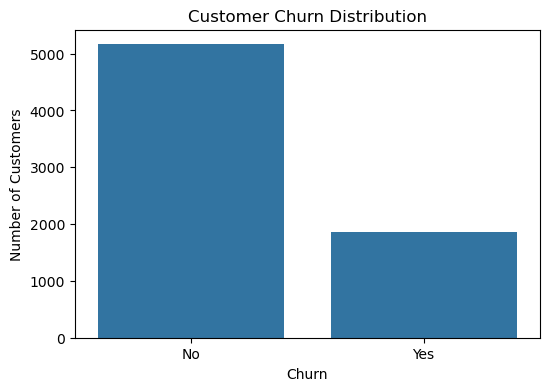

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

Save cleaned data

In [16]:
df.to_csv("cleaned_customer_churn.csv", index=False)

## Dataset Overview

This dataset contains customer information from a telecommunications company.

Target Variable:
- Churn (Yes/No)

Features include:
- Customer demographics
- Account information
- Service subscriptions
- Billing information

## Numerical statistics

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Questions to ask:

What is the average tenure?
What is the average monthly charge?
What is the maximum customer lifetime?

## Numerical distributions

## Tenure Distribution

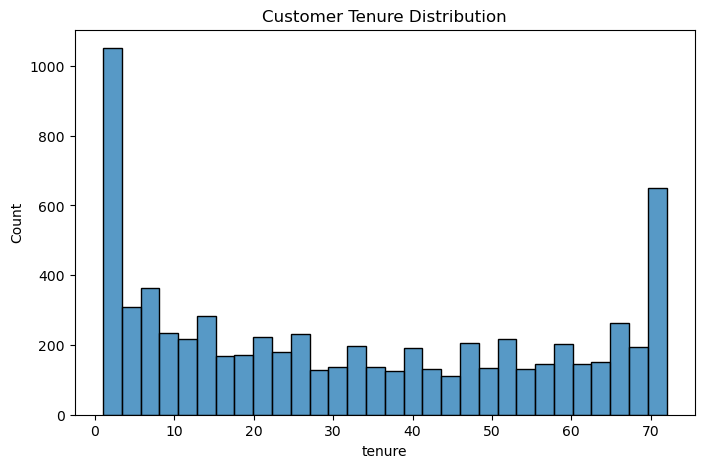

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30)
plt.title("Customer Tenure Distribution")
plt.show()

## Business Insight: 

Shows how long customers stay with the company.

## Monthly Charges Distribution

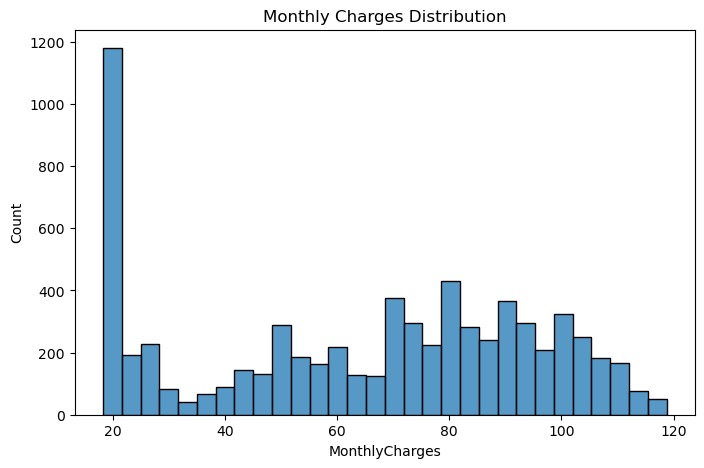

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

## Total Charges Distribution

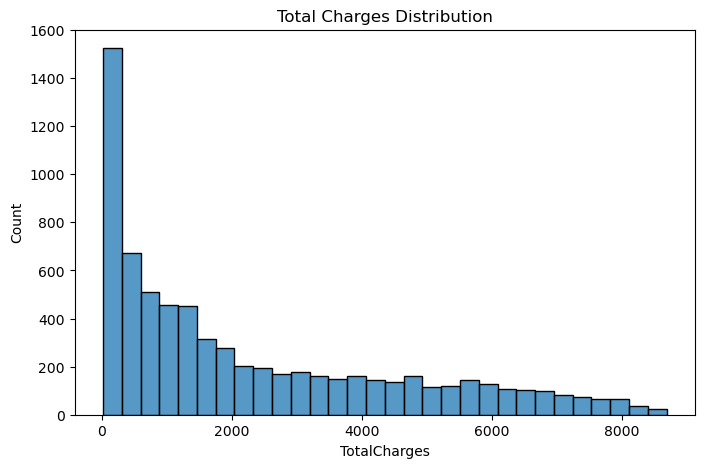

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalCharges"], bins=30)
plt.title("Total Charges Distribution")
plt.show()

## Churn by Contract Type

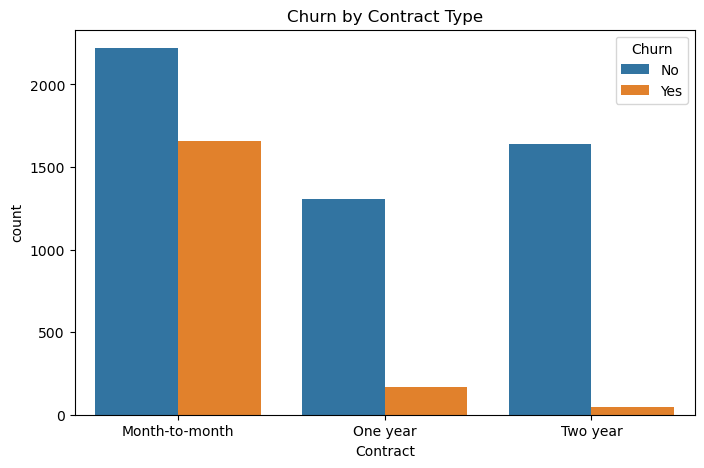

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.show()

Month-to-month customers churn more.
One-year and two-year contracts retain customers better.

## Churn by Payment Method

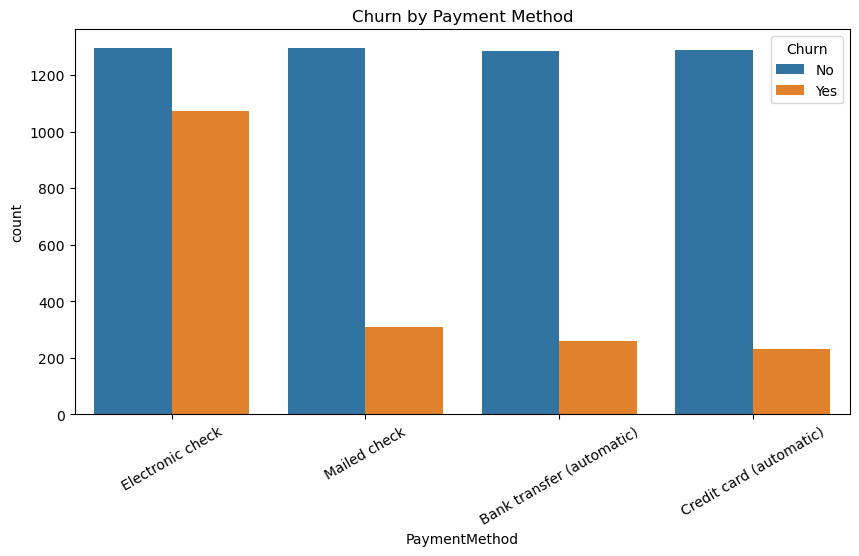

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=30)
plt.title("Churn by Payment Method")
plt.show()

The highest churn count is: Electronic Check — approximately 1,075 churned customers (Yes)

## Churn by Internet Service

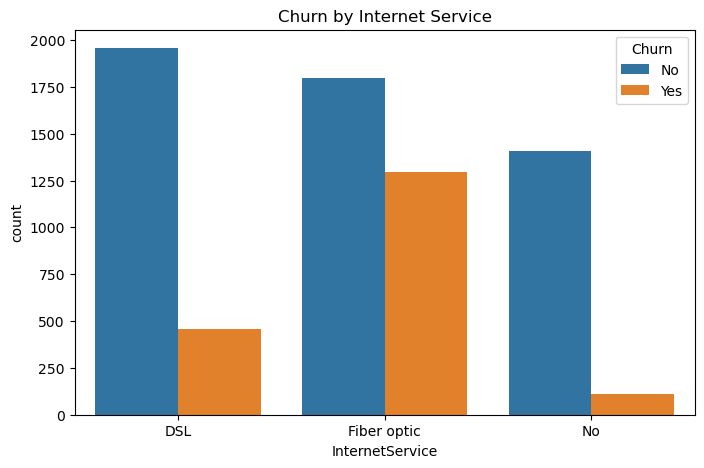

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.show()

## Churn by Senior Citizen

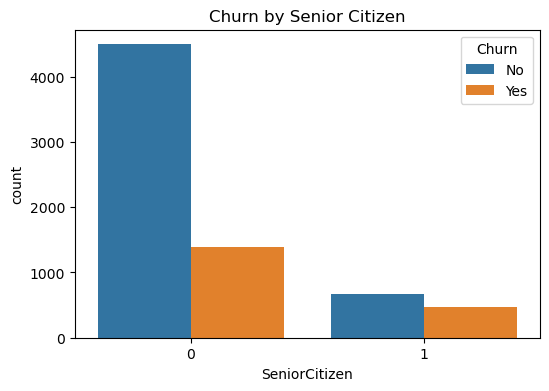

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Churn by Senior Citizen")
plt.show()

## Churn by Gender

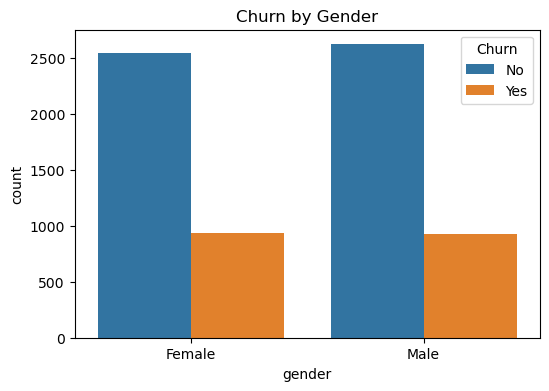

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Churn by Gender")
plt.show()

Gender has little impact on churn.

## Monthly Charges vs Churn

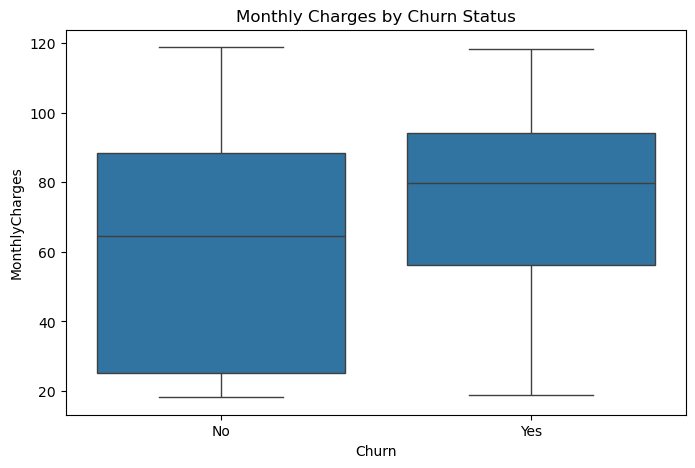

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.show()

Do churned customers pay more?

Yes

## Tenure vs Churn

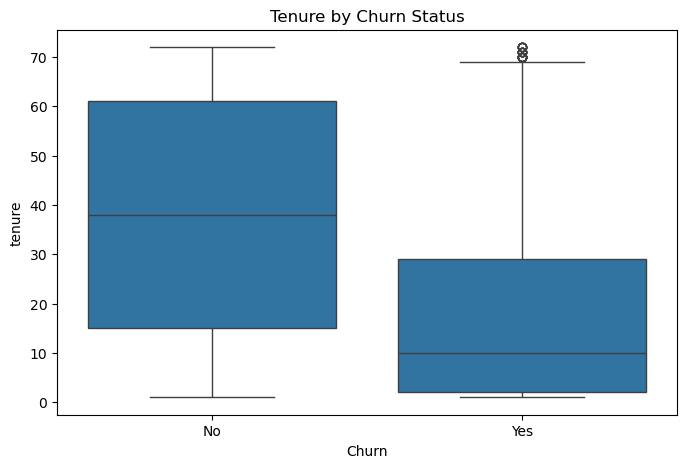

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn Status")
plt.show()

Customers who churn have significantly shorter tenure.

## Correlation Heatmap

create numeric copy

In [28]:
numeric_df = df.copy()

Convert Yes/No columns

In [29]:
numeric_df["Churn"] = numeric_df["Churn"].map({
    "Yes":1,
    "No":0
})

Select numeric columns

In [30]:
corr = numeric_df.select_dtypes(include=["int64","float64"]).corr()

## Heatmap

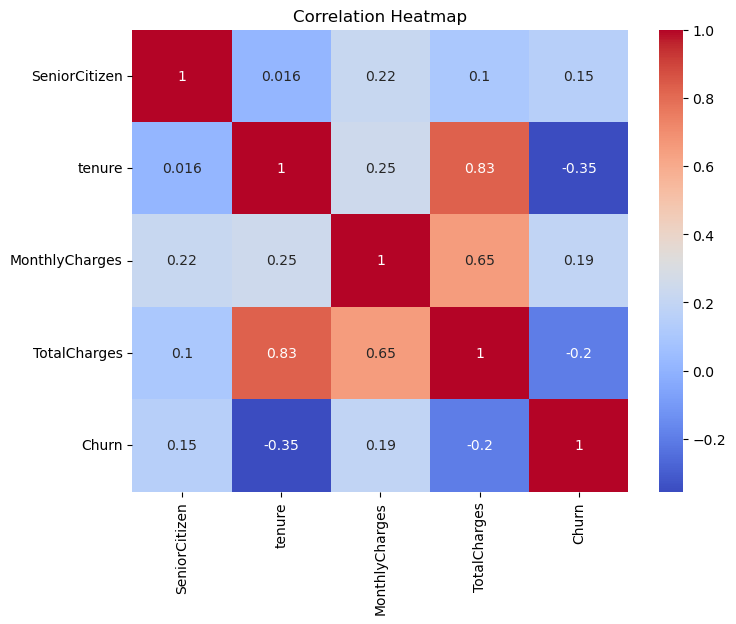

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## Create Tenure Groups

In [32]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4-6 Years"
    ]
)

Check

In [33]:
df["TenureGroup"].value_counts()

TenureGroup
4-6 Years    2239
0-1 Year     2175
2-4 Years    1594
1-2 Years    1024
Name: count, dtype: int64

## Churn by Tenure Group

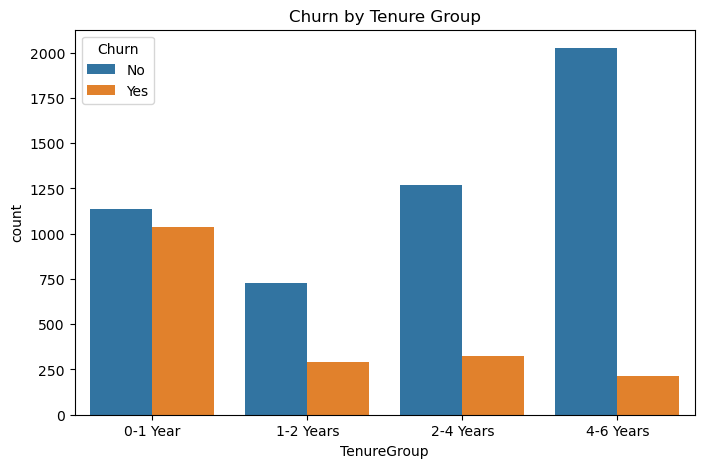

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Churn by Tenure Group")
plt.show()

Most churn happens in the first year.
Retention efforts should focus on new customers.

## Save Important Charts

## Churn Distribution

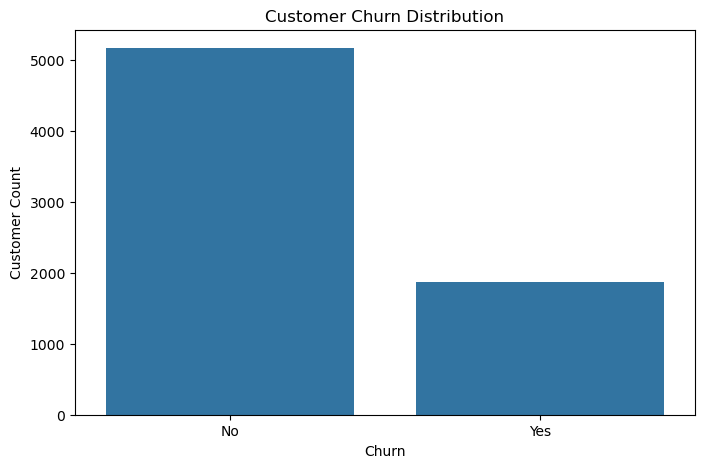

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")

plt.savefig(
    "churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight: Churn Distribution

The majority of customers remain with the company, while a smaller but significant portion have churned.

Although retained customers outnumber churned customers, the churn rate is high enough to impact revenue and customer acquisition costs.

Reducing churn should be a key business objective because retaining existing customers is generally less expensive than acquiring new ones.

## Churn by Contract Type

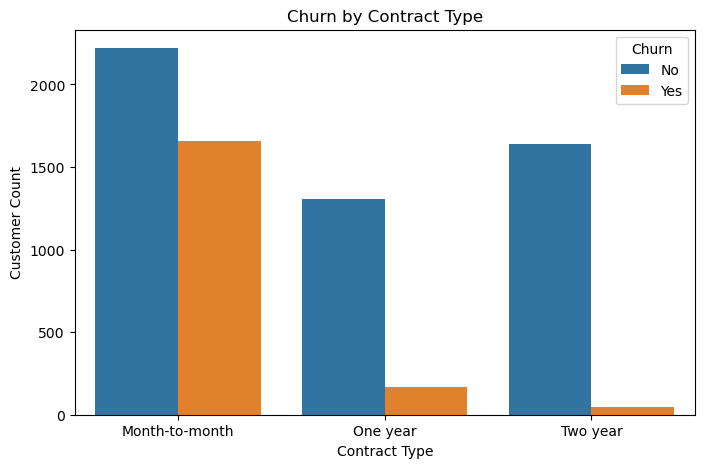

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")

plt.savefig(
    "churn_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight: Contract Type

Customers on month-to-month contracts show the highest churn levels compared to customers on one-year and two-year contracts.

Longer contract commitments appear to improve customer retention and reduce customer turnover.

This suggests that contract duration is one of the strongest indicators of customer loyalty.

### Recommendation

Encourage month-to-month customers to switch to longer-term contracts through discounts, loyalty rewards, or bundled services.

## Churn by Payment Method

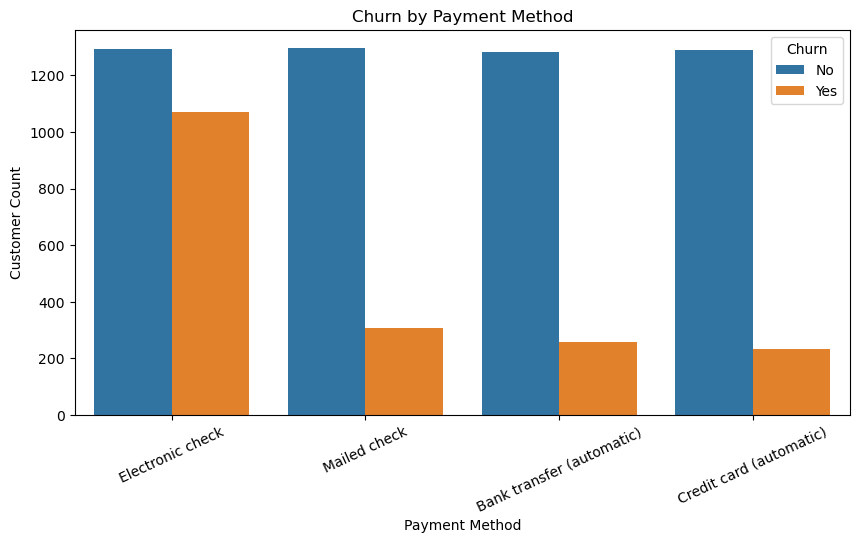

In [37]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.xticks(rotation=25)

plt.savefig(
    "churn_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight: Payment Method

Customers using Electronic Check exhibit the highest churn levels among all payment methods.

Customers using automatic payment methods such as Bank Transfer and Credit Card show considerably lower churn.

This suggests that automated billing methods may contribute to stronger customer retention and more stable customer relationships.

### Recommendation

Provide incentives for Electronic Check customers to migrate to automatic payment methods.

Examples include:
- Automatic payment discounts
- Loyalty rewards
- Simplified billing options

## Monthly Charges vs Churn

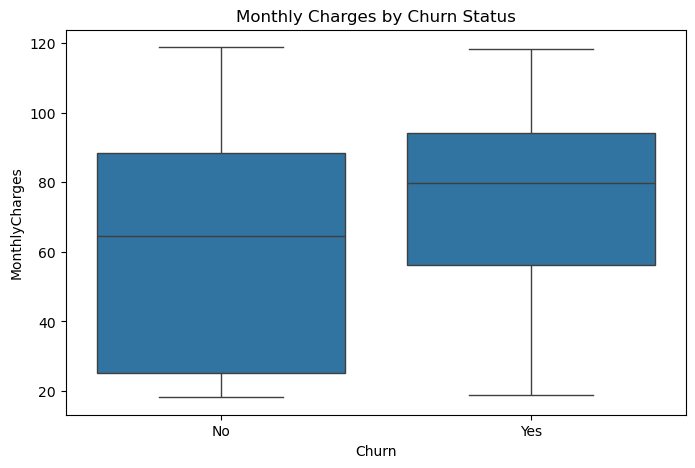

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")

plt.savefig(
    "monthly_charges_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight: Monthly Charges

Customers who churn generally have higher monthly charges than customers who remain with the company.

The median monthly charge for churned customers is noticeably higher, indicating that pricing may influence customer satisfaction and retention.

Customers paying higher monthly fees may expect greater value and service quality.

### Recommendation

Monitor high-paying customers closely and offer targeted retention programs such as:
- Loyalty discounts
- Premium customer support
- Personalized service plans
- Value-added features

## Churn by Tenure Group

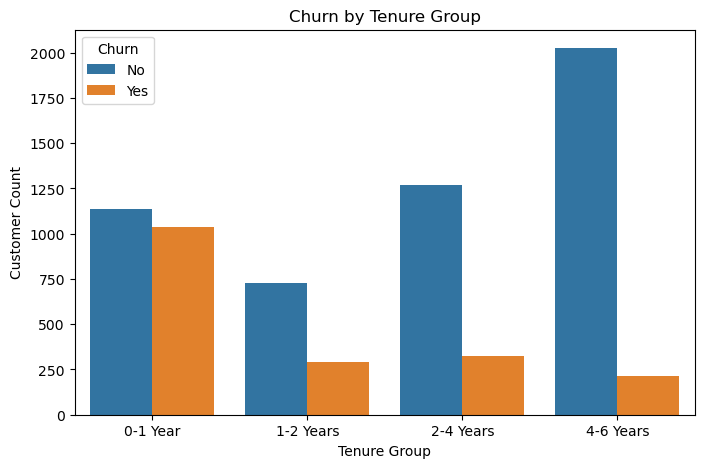

In [39]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4-6 Years"
    ]
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Customer Count")

plt.savefig(
    "churn_by_tenure_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight: Customer Tenure

Most churn occurs during the first year of a customer's relationship with the company.

Customers who remain beyond the early stages tend to stay with the company for much longer periods.

The first year represents the highest-risk period for customer loss.

### Recommendation

Implement customer onboarding programs, welcome offers, and proactive support during the first year to improve retention rates.

## SQL

In [40]:
df = pd.read_csv("cleaned_customer_churn.csv")

conn = sqlite3.connect("customer_churn.db")

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

pd.read_sql("SELECT * FROM customers LIMIT 5;", conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn Rate

In [41]:
query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

pd.read_sql(query, conn)

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1472,166,11.28
2,Two year,1685,48,2.85


## Business Insight

Out of 7,032 customers, 1,869 customers have churned while 5,163 customers remain active.

The churn rate is approximately 26.6%, meaning roughly one out of every four customers leaves the company. This indicates a significant opportunity for customer retention improvements.

Contract Type Analysis

In [42]:
query = """
SELECT
    Contract,
    Churn,
    COUNT(*) AS customers
FROM customers
GROUP BY Contract, Churn
ORDER BY Contract;
"""

pd.read_sql(query, conn)

,Contract,Churn,customers
0,Month-to-month,No,2220
1,Month-to-month,Yes,1655
2,One year,No,1306
3,One year,Yes,166
4,Two year,No,1637
5,Two year,Yes,48


Payment Method Analysis

In [43]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
"""

pd.read_sql(query, conn)

,PaymentMethod,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1604,308,19.20
2,Bank transfer (automatic),1542,258,16.73
3,Credit card (automatic),1521,232,15.25


Monthly Charges Analysis

In [44]:
query = """
SELECT
    Churn,
    ROUND(AVG(MonthlyCharges),2) AS avg_monthly_charge,
    ROUND(MIN(MonthlyCharges),2) AS min_charge,
    ROUND(MAX(MonthlyCharges),2) AS max_charge
FROM customers
GROUP BY Churn;
"""

pd.read_sql(query, conn)

,Churn,avg_monthly_charge,min_charge,max_charge
0,No,61.31,18.25,118.75
1,Yes,74.44,18.85,118.35


Tenure Analysis

In [45]:
query = """
SELECT
    Churn,
    ROUND(AVG(tenure),2) AS avg_tenure
FROM customers
GROUP BY Churn;
"""

pd.read_sql(query, conn)

,Churn,avg_tenure
0,No,37.65
1,Yes,17.98


Internet Service Analysis

In [46]:
query = """
SELECT
    InternetService,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

pd.read_sql(query, conn)

,InternetService,total_customers,churned_customers,churn_rate
0,Fiber optic,3096,1297,41.89
1,DSL,2416,459,19.00
2,No,1520,113,7.43


Senior Citizen Analysis

In [47]:
query = """
SELECT
    SeniorCitizen,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY SeniorCitizen;
"""

pd.read_sql(query, conn)

,SeniorCitizen,total_customers,churned_customers,churn_rate
0,0,5890,1393,23.65
1,1,1142,476,41.68


Top Revenue Customers

In [48]:
query = """
SELECT
    customerID,
    tenure,
    MonthlyCharges,
    TotalCharges
FROM customers
ORDER BY TotalCharges DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,customerID,tenure,MonthlyCharges,TotalCharges
0,2889-FPWRM,72,117.80,8684.80
1,7569-NMZYQ,72,118.75,8672.45
2,9739-JLPQJ,72,117.50,8670.10
3,9788-HNGUT,72,116.95,8594.40
4,8879-XUAHX,71,116.25,8564.75
5,9924-JPRMC,72,118.20,8547.15
6,0675-NCDYU,72,116.40,8543.25
7,6650-BWFRT,72,117.15,8529.50
8,0164-APGRB,72,114.90,8496.70
9,1488-PBLJN,72,116.85,8477.70


Revenue Lost from Churn

In [49]:
query = """
SELECT
    ROUND(SUM(MonthlyCharges),2) AS lost_monthly_revenue
FROM customers
WHERE Churn='Yes';
"""

pd.read_sql(query, conn)

,lost_monthly_revenue
0,139130.85


Highest Churn Risk Segments

In [50]:
query = """
SELECT
    Contract,
    PaymentMethod,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract, PaymentMethod
HAVING COUNT(*) > 50
ORDER BY churn_rate DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Contract,PaymentMethod,customers,churned_customers,churn_rate
0,Month-to-month,Electronic check,1850,994,53.73
1,Month-to-month,Bank transfer (automatic),589,201,34.13
2,Month-to-month,Credit card (automatic),543,178,32.78
3,Month-to-month,Mailed check,893,282,31.58
4,One year,Electronic check,347,64,18.44
5,One year,Credit card (automatic),398,41,10.30
6,One year,Bank transfer (automatic),391,38,9.72
7,Two year,Electronic check,168,13,7.74
8,One year,Mailed check,336,23,6.85
9,Two year,Bank transfer (automatic),562,19,3.38


# Executive Summary

## Key Findings

1. Overall churn rate is approximately 26.6%.
2. Month-to-month contracts have the highest churn rate.
3. Electronic Check customers are more likely to churn.
4. Customers with higher monthly charges tend to churn more frequently.
5. Customers with shorter tenure are at higher risk of churn.
6. Significant monthly revenue is lost due to customer churn.

## Recommendations

1. Encourage customers to adopt long-term contracts.
2. Promote automatic payment methods.
3. Focus retention efforts on new customers.
4. Monitor high-value customers closely.
5. Develop targeted retention campaigns for high-risk customer segments.